In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mnist = pd.read_csv("data/mnist-train.csv")
mnist

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
X = mnist.drop(columns = "label").copy()
y = mnist["label"].copy()

In [3]:
X = X / 255

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [5]:
X_train.shape

(33600, 784)

In [6]:
from classes.MyNeuralNetwork import MyNeuralNetworkClassifier

my_nn = MyNeuralNetworkClassifier([100, 20], X.shape[-1], classes = 10)

In [7]:
def create_batches(X, y, size = 128):
    if X.shape[0] != y.shape[0]:
        raise Exception("Num. de muestras no concuerdan en X y y")
    ini = 0
    samples = X.shape[0]
    batches = [(X[i:i+size], y[i:i+size]) for i in range(0, samples, size)]
    return batches

In [8]:
training_data = create_batches(X_train, y_train)
len(training_data)

263

In [9]:
loss_values = []
for (batch_x, batch_y) in training_data:
    loss = my_nn.fit(batch_x, batch_y, return_loss = True)
    loss_values.append(loss)

In [ ]:
print(loss_values[:-5])

[1.8319344614057975, 1.4765459640674845, 1.3174146058346112, 0.9490366965201859, 0.8246257840268856, 0.7765477934390165, 0.6311191209561313, 0.5139024452629327, 0.46524070963652137, 0.4872137861777516, 0.4042636937190627, 0.39064397692311836, 0.3295534323886758, 0.33882027854522867, 0.2999193241838419, 0.28793369729145485, 0.47509921137341776, 0.35791875724565947, 0.19677763423668782, 0.3002799636061463, 0.4756385742979903, 0.3166760430611117, 0.2933371583249337, 0.21776414292478602, 0.19631501734151968, 0.23668198415431577, 0.2495393688497663, 0.21214512426101642, 0.19023323725485503, 0.24165640939497557, 0.25563424746029517, 0.2009806414934617, 0.24902726415301335, 0.24397969884383025, 0.26240859148814877, 0.2511643016053203, 0.13938963819351646, 0.281994129678527, 0.24905165919048933, 0.17583935055754923, 0.23769610038647465, 0.17402810083817455, 0.20021555107569253, 0.2640296927188668, 0.29770704816002913, 0.14341221079787814, 0.16840169784665263, 0.17335824265332195, 0.28927520550

Text(0, 0.5, 'Cross Entropy Loss')

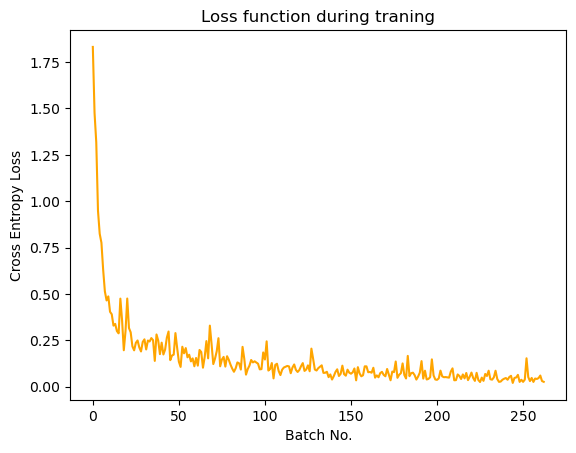

In [10]:
plt.figure()
plt.plot(range(len(loss_values)), loss_values, c = "orange")
plt.title("Loss function during traning")
plt.xlabel("Batch No.")
plt.ylabel("Cross Entropy Loss")

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix

predictions = my_nn.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, predictions))


Accuracy score: 0.9234523809523809


In [12]:
conf_matrix = confusion_matrix(y_test, predictions)

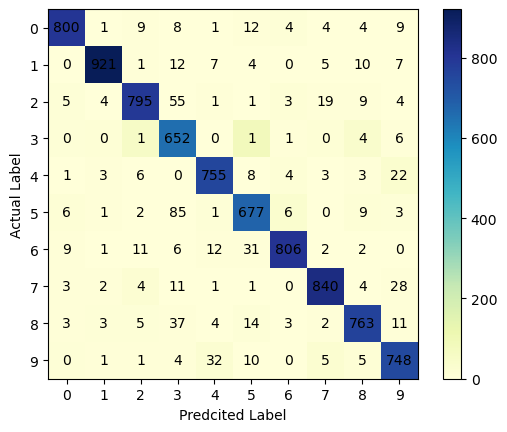

In [13]:
plt.figure()
plt.imshow(conf_matrix, cmap = "YlGnBu")
plt.xticks(range(10))
plt.yticks(range(10))
plt.ylabel("Actual Label")
plt.xlabel("Predcited Label")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(i, j, conf_matrix[i, j], ha = "center", va = "center", color = "black")

Label: 17318    5
Name: label, dtype: int64
Predicted: 6


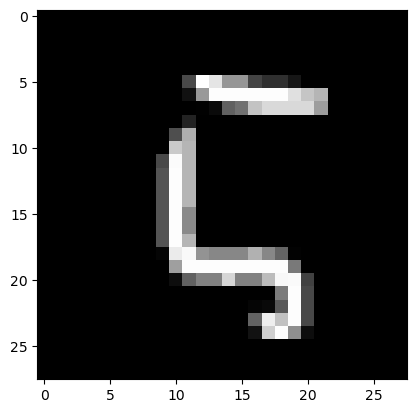

In [34]:
mask = (y_test != predictions)
incorrect = y_test[mask]
incorrect_predictions = predictions[mask]
pos = np.random.randint(0, incorrect.shape[0])
idx = incorrect[pos:pos+1].index
num = X_test.loc[idx].to_numpy().reshape((28, 28))
plt.imshow(num, cmap = plt.get_cmap("gray"))
print("Label:", y_test.loc[idx])
print("Predicted:", incorrect_predictions[pos])

In [15]:
print(predictions.shape)

(8400,)
